# Lab 4

## Imports & Loading The Data

In [1]:
#You may need to add other libraries here depending on your code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

df_train = pd.read_csv('training.csv')
df_test = pd.read_csv('testing.csv')

df_train_cleaned = df_train.iloc[:, :10]
df_test_cleaned = df_test.iloc[:, :10]

print(df_train_cleaned.columns)
print(df_test_cleaned.columns)

print(df_train_cleaned['class'].value_counts())
print(df_test_cleaned['class'].value_counts())

Index(['class', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9'], dtype='object')
Index(['class', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9'], dtype='object')
class
s    136
d    105
o     46
h     38
Name: count, dtype: int64
class
s    59
d    54
h    48
o    37
Name: count, dtype: int64


## Prepare Data

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

X_train = df_train_cleaned.drop('class', axis=1)
y_train = df_train_cleaned['class']

X_test = df_test_cleaned.drop('class', axis=1)
y_test = df_test_cleaned['class']

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(decision_function_shape='ovo'))
])

## Find Best Hyperparams

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

grid_search = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', verbose=1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_index = grid_search.best_index_

fold_0_score = grid_search.cv_results_['split0_test_score'][best_index]
fold_1_score = grid_search.cv_results_['split1_test_score'][best_index]
fold_2_score = grid_search.cv_results_['split2_test_score'][best_index]

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Validation Fold 1 Accuracy: {fold_0_score:.4f}")
print(f"Validation Fold 2 Accuracy: {fold_1_score:.4f}")
print(f"Validation Fold 3 Accuracy: {fold_2_score:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'svm__C': 1, 'svm__kernel': 'rbf'}
Validation Fold 1 Accuracy: 0.8624
Validation Fold 2 Accuracy: 0.9259
Validation Fold 3 Accuracy: 0.8889


## Train Final Model

Training Accuracy (Scaled): 0.9077
Test Accuracy (Scaled): 0.9192


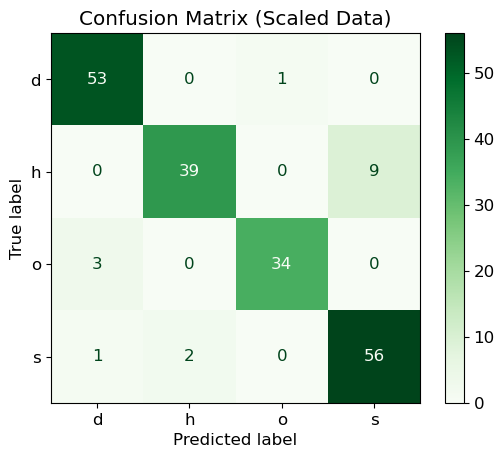

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = grid_search.best_estimator_

train_acc = best_model.score(X_train, y_train)
test_acc = best_model.score(X_test, y_test)

print(f"Training Accuracy (Scaled): {train_acc:.4f}")
print(f"Test Accuracy (Scaled): {test_acc:.4f}")

y_pred = best_model.predict(X_test)
cmd = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                              display_labels=best_model.classes_,
                                              cmap='Greens')
plt.title("Confusion Matrix (Scaled Data)")
plt.show()

## Repeat Without Scaling

In [13]:
# 5. Repeat without scaling
# Define a simple SVC without the pipeline/scaler
svm_no_scale = SVC(decision_function_shape='ovo')

# Same parameter grid (note: no 'svm__' prefix needed if not in a pipeline)
param_grid_simple = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

grid_no_scale = GridSearchCV(svm_no_scale, param_grid_simple, cv=3, scoring='accuracy')
grid_no_scale.fit(X_train, y_train)

# Performance Indicators
no_scale_train_acc = grid_no_scale.score(X_train, y_train)
no_scale_test_acc = grid_no_scale.score(X_test, y_test)

print(f"Best Params (No Scale): {grid_no_scale.best_params_}")
print(f"Training Accuracy (No Scale): {no_scale_train_acc:.4f}")
print(f"Test Accuracy (No Scale): {no_scale_test_acc:.4f}")

# Comparison Table
comparison_data = {
    "Metric": ["Best Kernel", "Best C", "Train Accuracy", "Test Accuracy"],
    "With Scaling": [best_params['svm__kernel'], best_params['svm__C'], train_acc, test_acc],
    "Without Scaling": [grid_no_scale.best_params_['kernel'], grid_no_scale.best_params_['C'], 
                        no_scale_train_acc, no_scale_test_acc]
}
df_comp = pd.DataFrame(comparison_data)
display(df_comp)

Best Params (No Scale): {'C': 1, 'kernel': 'poly'}
Training Accuracy (No Scale): 0.9108
Test Accuracy (No Scale): 0.9091


,Metric,With Scaling,Without Scaling
0,Best Kernel,rbf,poly
1,Best C,1,1
2,Train Accuracy,0.907692,0.910769
3,Test Accuracy,0.919192,0.909091


## Logistic Regression Softmax

c:\Users\23709058\AppData\Local\miniconda3\envs\cits5508\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\23709058\AppData\Local\miniconda3\envs\cits5508\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\23709058\AppData\Local\miniconda3\envs\cits5508\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\23709058\AppData\Local\minicond

Optimal Softmax Params: {'lr__C': 10, 'lr__penalty': 'l1'}
Fold 1: 0.8716
Fold 2: 0.8981
Fold 3: 0.8426
Training Accuracy: 0.9046
Test Accuracy: 0.9192


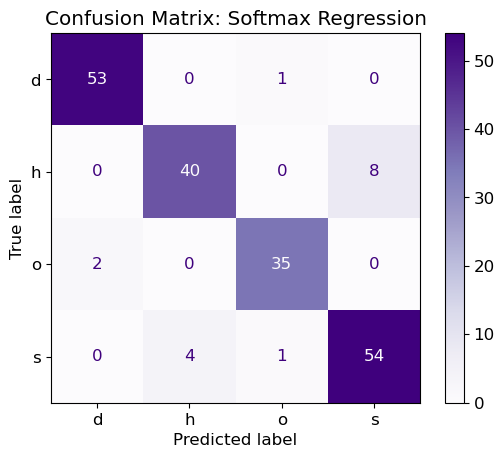

In [14]:
from sklearn.linear_model import LogisticRegression

# 1 & 2. Define Pipeline and Grid Search for Softmax Regression
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(multi_class='multinomial', solver='saga', max_iter=5000))
])

# Define hyperparameter grid
# C is inverse of regularization: smaller C = stronger regularization
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']  # SAGA solver supports both
}

lr_grid_search = GridSearchCV(lr_pipe, lr_param_grid, cv=3, scoring='accuracy')
lr_grid_search.fit(X_train, y_train)

# 3. Best Hyperparameters and Fold Performance
best_lr_idx = lr_grid_search.best_index_
print(f"Optimal Softmax Params: {lr_grid_search.best_params_}")
print(f"Fold 1: {lr_grid_search.cv_results_['split0_test_score'][best_lr_idx]:.4f}")
print(f"Fold 2: {lr_grid_search.cv_results_['split1_test_score'][best_lr_idx]:.4f}")
print(f"Fold 3: {lr_grid_search.cv_results_['split2_test_score'][best_lr_idx]:.4f}")

# 4. Final Performance Indicators
print(f"Training Accuracy: {lr_grid_search.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {lr_grid_search.score(X_test, y_test):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lr_grid_search, X_test, y_test, 
                                      display_labels=lr_grid_search.classes_, 
                                      cmap='Purples')
plt.title("Confusion Matrix: Softmax Regression")
plt.show()

## k-NN Implementation

Optimal K-NN Params: {'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Fold 1: 0.8165
Fold 2: 0.9167
Fold 3: 0.8611
Training Accuracy: 0.8923
Test Accuracy: 0.9141


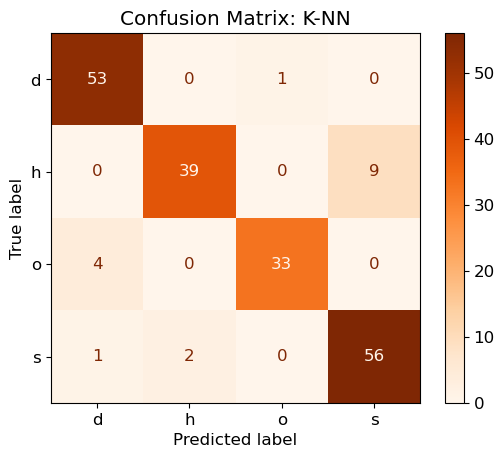

In [15]:
from sklearn.neighbors import KNeighborsClassifier

# 1 & 2. Define Pipeline and Grid Search for K-NN
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Define hyperparameter grid for K (n_neighbors)
knn_param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'] # Optional extra parameter to tune
}

knn_grid_search = GridSearchCV(knn_pipe, knn_param_grid, cv=3, scoring='accuracy')
knn_grid_search.fit(X_train, y_train)

# 3. Best Hyperparameters and Fold Performance
best_knn_idx = knn_grid_search.best_index_
print(f"Optimal K-NN Params: {knn_grid_search.best_params_}")
print(f"Fold 1: {knn_grid_search.cv_results_['split0_test_score'][best_knn_idx]:.4f}")
print(f"Fold 2: {knn_grid_search.cv_results_['split1_test_score'][best_knn_idx]:.4f}")
print(f"Fold 3: {knn_grid_search.cv_results_['split2_test_score'][best_knn_idx]:.4f}")

# 4. Final Performance Indicators
print(f"Training Accuracy: {knn_grid_search.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {knn_grid_search.score(X_test, y_test):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(knn_grid_search, X_test, y_test, 
                                      display_labels=knn_grid_search.classes_, 
                                      cmap='Oranges')
plt.title("Confusion Matrix: K-NN")
plt.show()